# Photon Tracer Example Usage

This notebook demonstrates how to use the `photon_tracer` package to simulate photon propagation through a multi-layer optical detector.

## Overview

We'll simulate VUV photons (128 nm) from a liquid argon scintillation source propagating through:
1. **Bulk LAr** - Source region
2. **Dichroic Mirror** - Wavelength-selective reflector
3. **WLS (TPB)** - Converts VUV → blue (420 nm)
4. **Light Collection (EJ280)** - Converts blue → green (490 nm)
5. **Sensors** - Detect shifted photons

In [1]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from photon_tracer import Cuboid, PhotonSimulation
from photon_tracer.simulation import SimulationConfig
from photon_tracer.analysis import (
    plot_geometry_3d,
    plot_trajectories,
    plot_event_statistics,
    plot_path_length_distribution,
    compute_geometric_efficiency,
)

print("✓ Imports successful")

✓ Imports successful


## 1. Define Detector Geometry

We'll create a simplified detector with 4 regions stacked along the x-axis.

In [2]:
# Geometry parameters
width = 0.5   # meters
height = 0.5  # meters

# Layer thicknesses
lc_x = 1e-2      # Light collection: 1 cm
wls_x = 3e-6     # WLS (TPB): 3 microns
dm_x = 112e-6    # Dichroic mirror: 112 microns
bulk_x = 0.5     # Bulk LAr: 50 cm

print(f"Detector dimensions:")
print(f"  LC thickness:   {lc_x*1e2:.1f} cm")
print(f"  WLS thickness:  {wls_x*1e6:.1f} µm")
print(f"  DM thickness:   {dm_x*1e6:.0f} µm")
print(f"  Bulk depth:     {bulk_x*1e2:.0f} cm")

Detector dimensions:
  LC thickness:   1.0 cm
  WLS thickness:  3.0 µm
  DM thickness:   112 µm
  Bulk depth:     50 cm


In [3]:
# Build geometry layer by layer
x_pos = 0.0

# Light Collection region (EJ280)
lc_min = np.array([x_pos, 0, 0])
lc_max = np.array([x_pos + lc_x, height, width])
x_pos += lc_x

# WLS (TPB)
wls_min = np.array([x_pos, 0, 0])
wls_max = np.array([x_pos + wls_x, height, width])
x_pos += wls_x

# Dichroic Mirror
dm_min = np.array([x_pos, 0, 0])
dm_max = np.array([x_pos + dm_x, height, width])
x_pos += dm_x

# Bulk LAr
bulk_min = np.array([x_pos, 0, 0])
bulk_max = np.array([bulk_x, height, width])

print(f"✓ Geometry defined")

✓ Geometry defined


## 2. Define Source and Sensors

In [4]:
# Isotropic point source at far end of bulk
source_position = np.array([bulk_max[0], height/2, width/2])

# Array of sensors on LC face
n_sipms = 6
sensor_positions = np.array([
    [lc_x/2, (1 + 2*i)/(2*n_sipms) * height, 0.0]
    for i in range(n_sipms)
])
sensor_radius = 0.01  # 1 cm detection radius

print(f"Source at: {source_position}")
print(f"Number of sensors: {n_sipms}")
print(f"Sensor radius: {sensor_radius*100:.1f} cm")

Source at: [0.5  0.25 0.25]
Number of sensors: 6
Sensor radius: 1.0 cm


## 3. Define Material Properties

Each volume has wavelength-dependent optical properties.

In [5]:
# EJ280 (Light Collection) properties
mu_a_lc = {
    128.0: 0.0,    # No VUV absorption
    420.0: 20.0,   # Absorbs blue (5 cm absorption length)
    490.0: 0.2,    # Transparent at emission
}

# TPB (Wavelength Shifter) properties
mu_a_tpb = {
    128.0: 5e5,    # Strong VUV absorption (2 µm length)
    420.0: 10.0,   # Transparent to blue
    490.0: 1.0,    # Transparent to green
}

# Dichroic mirror reflectance
dm_reflectance = {
    128.0: 0.2,    # Low VUV reflectance
    420.0: 0.95,   # High blue reflectance (reflects back!)
    490.0: 0.10,   # Low green reflectance (transmits through)
}

print("✓ Material properties defined")

✓ Material properties defined


## 4. Create Volume Objects

In [6]:
# Light Collection (EJ280) - shifts blue to green
lc = Cuboid(
    min_point=lc_min,
    max_point=lc_max,
    refractive_index={128: 1.65, 420: 1.60, 490: 1.58},
    name="lc",
    wls=True,
    mu_a=mu_a_lc,
    quantum_yield=0.95,
    emission_peak_nm=490.0,
    emission_sigma_nm=20.0,
)

# Wavelength Shifter (TPB) - shifts VUV to blue
wls = Cuboid(
    min_point=wls_min,
    max_point=wls_max,
    refractive_index={128: 1.70, 420: 1.62, 490: 1.60},
    name="wls",
    wls=True,
    mu_a=mu_a_tpb,
    quantum_yield=0.9,
    emission_peak_nm=420.0,
    emission_sigma_nm=15.0,
)

# Dichroic Mirror - wavelength-selective reflector
dm = Cuboid(
    min_point=dm_min,
    max_point=dm_max,
    refractive_index={128: 1.5, 420: 1.65, 490: 1.9},
    name="dm",
    wls=False,
    is_dichroic=True,
    reflectance=dm_reflectance,
)

# Bulk LAr - transparent source region
bulk = Cuboid(
    min_point=bulk_min,
    max_point=bulk_max,
    refractive_index={128: 1.6, 420: 1.23, 490: 1.22},
    name="bulk",
    wls=False,
)

volumes = [lc, wls, dm, bulk]

print(f"✓ Created {len(volumes)} volumes:")
for v in volumes:
    print(f"  - {v.name}: WLS={v.wls}, Dichroic={v.is_dichroic}")

✓ Created 4 volumes:
  - lc: WLS=True, Dichroic=False
  - wls: WLS=True, Dichroic=False
  - dm: WLS=False, Dichroic=True
  - bulk: WLS=False, Dichroic=False


## 5. Visualize Geometry

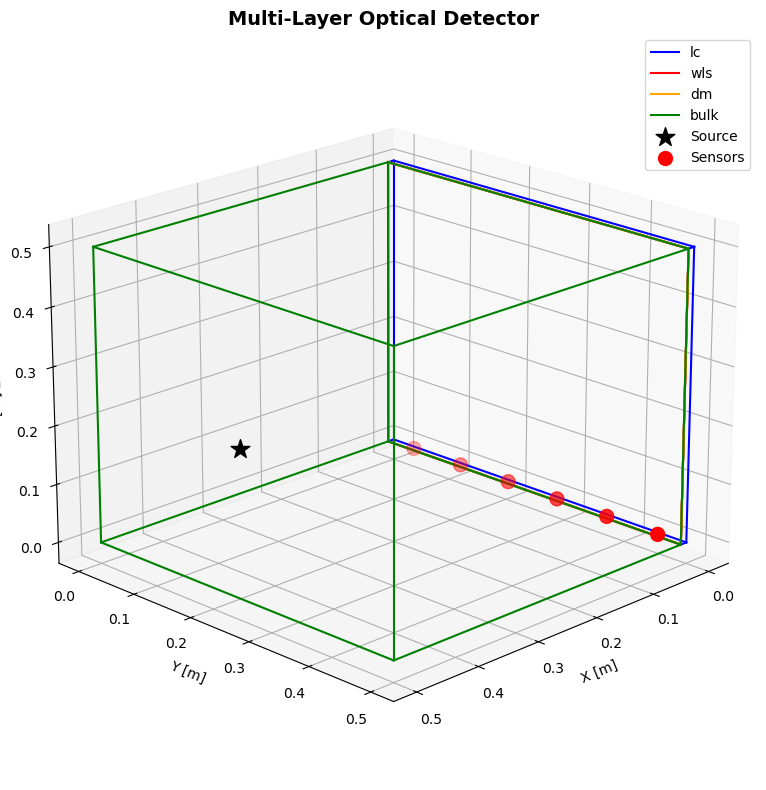

Blue = LC, Red = WLS, Orange = DM, Green = Bulk
Black star = Source, Red spheres = Sensors


In [7]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

plot_geometry_3d(
    volumes,
    source_position,
    sensor_positions,
    ax=ax,
    colors=['blue', 'red', 'orange', 'green']
)

ax.set_title("Multi-Layer Optical Detector", fontsize=14, fontweight='bold')
ax.view_init(elev=20, azim=45)
plt.tight_layout()
plt.show()

print("Blue = LC, Red = WLS, Orange = DM, Green = Bulk")
print("Black star = Source, Red spheres = Sensors")

## 6. Configure and Run Simulation

For this demo, we'll use a moderate number of photons for reasonable runtime (~30 seconds).

In [8]:
# Configuration
config = SimulationConfig(
    num_photons=1000,      # Target successful detections
    max_thrown=10000,      # Maximum to throw
    max_steps=5000,        # Max propagation steps per photon
    max_workers=4,         # Parallel threads
    initial_wavelength_nm=128.0,  # LAr scintillation (VUV)
    rng_seed=42,           # For reproducibility
)

print("Configuration:")
print(f"  Target photons: {config.num_photons}")
print(f"  Max thrown: {config.max_thrown}")
print(f"  Initial λ: {config.initial_wavelength_nm} nm (VUV)")
print(f"  Parallel workers: {config.max_workers}")

Configuration:
  Target photons: 1000
  Max thrown: 10000
  Initial λ: 128.0 nm (VUV)
  Parallel workers: 4


In [9]:
# Create simulation object
sim = PhotonSimulation(
    volumes=volumes,
    source_position=source_position,
    sensor_positions=sensor_positions,
    sensor_radius=sensor_radius,
    config=config,
)

print("✓ Simulation object created")
print(f"  {len(sim.volumes)} volumes")
print(f"  {len(sim.sensor_positions)} sensors")

✓ Simulation object created
  4 volumes
  6 sensors


In [10]:
# Run simulation (this may take 30-60 seconds)
print("Running simulation...\n")
df = sim.run(verbose=True)
print("\n✓ Simulation complete!")

Running simulation...



Photon tracing: 100%|██████████| 10000/10000 [00:00<00:00, 488561.91it/s]


Simulation complete:
  Total thrown: 10000
  Arrived: 1
  Efficiency: 0.010%
  Time: 1.23 s

Fates:
  lost_dm: 470
  lost_bulk: 9529

✓ Simulation complete!


## 7. Analyze Results

In [11]:
# Quick statistics
n_arrived = (df['event_type'] == 'arrived').sum()
n_total = len(df)
efficiency = 100 * n_arrived / n_total

print("=" * 60)
print("RESULTS SUMMARY")
print("=" * 60)
print(f"Total photons thrown: {n_total:,}")
print(f"Successfully detected: {n_arrived:,}")
print(f"Raw efficiency: {efficiency:.3f}%")
print()
print("Event breakdown:")
print(df['event_type'].value_counts())
print("=" * 60)

RESULTS SUMMARY
Total photons thrown: 10,000
Successfully detected: 1
Raw efficiency: 0.010%

Event breakdown:
event_type
lost_bulk    9529
lost_dm       470
arrived         1
Name: count, dtype: int64


In [12]:
# Compute geometric efficiency
solid_angle, geom_frac = compute_geometric_efficiency(
    source_position=source_position,
    target_cuboid=dm,
    target_face="xmax"  # Face closest to source
)

corrected_eff = efficiency / geom_frac if geom_frac > 0 else 0

print(f"\nGeometric Analysis:")
print(f"  Solid angle: {solid_angle:.6f} sr")
print(f"  Geometric fraction: {geom_frac:.6e} ({geom_frac*100:.2f}% of 4π)")
print(f"  Corrected efficiency: {corrected_eff:.2f}%")
print(f"\nInterpretation:")
print(f"  Only {geom_frac*100:.1f}% of isotropic photons even head toward detector!")
print(f"  Of those, {corrected_eff:.1f}% successfully reach sensors.")


Geometric Analysis:
  Solid angle: 0.832478 sr
  Geometric fraction: 6.624646e-02 (6.62% of 4π)
  Corrected efficiency: 0.15%

Interpretation:
  Only 6.6% of isotropic photons even head toward detector!
  Of those, 0.2% successfully reach sensors.


## 8. Visualize Results

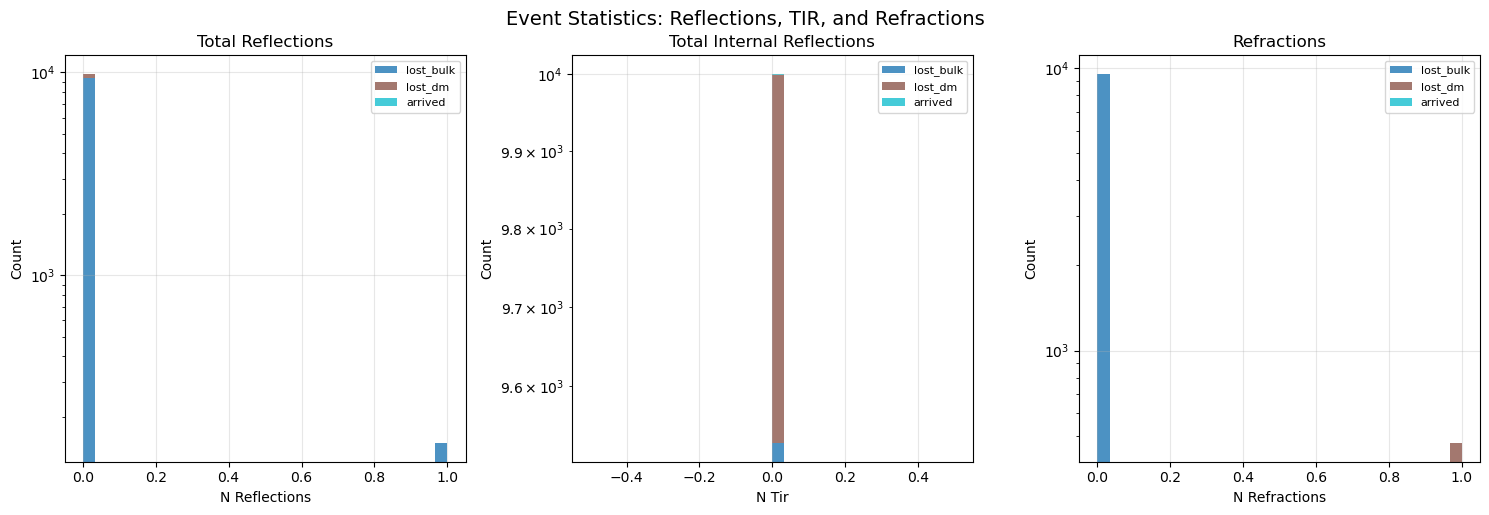

In [13]:
# Event statistics
fig = plot_event_statistics(df, figsize=(15, 5))
plt.suptitle("Event Statistics: Reflections, TIR, and Refractions", fontsize=14, y=1.02)
plt.show()

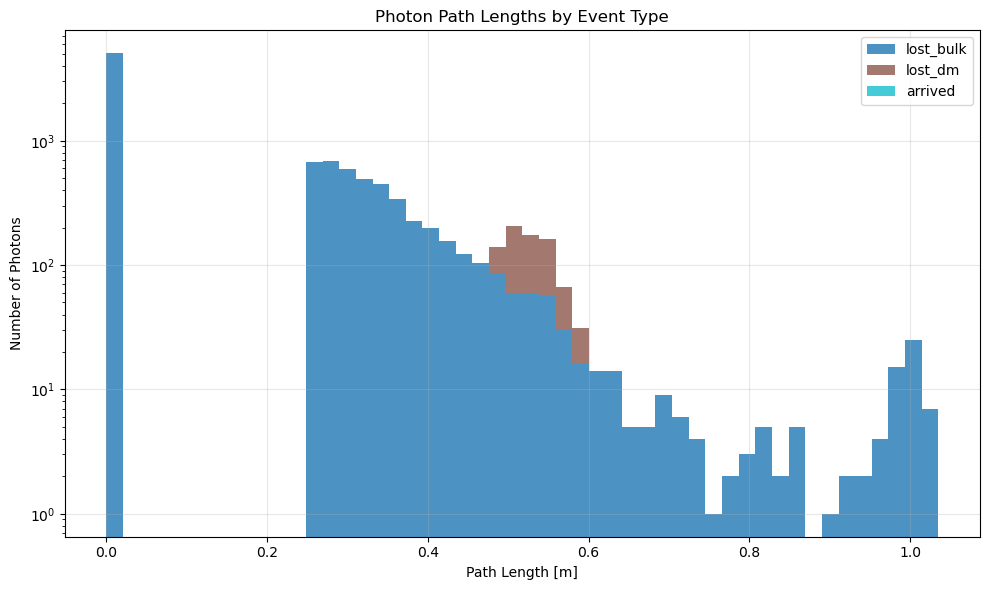

In [14]:
# Path length distribution
fig = plot_path_length_distribution(df, figsize=(10, 6))
plt.show()

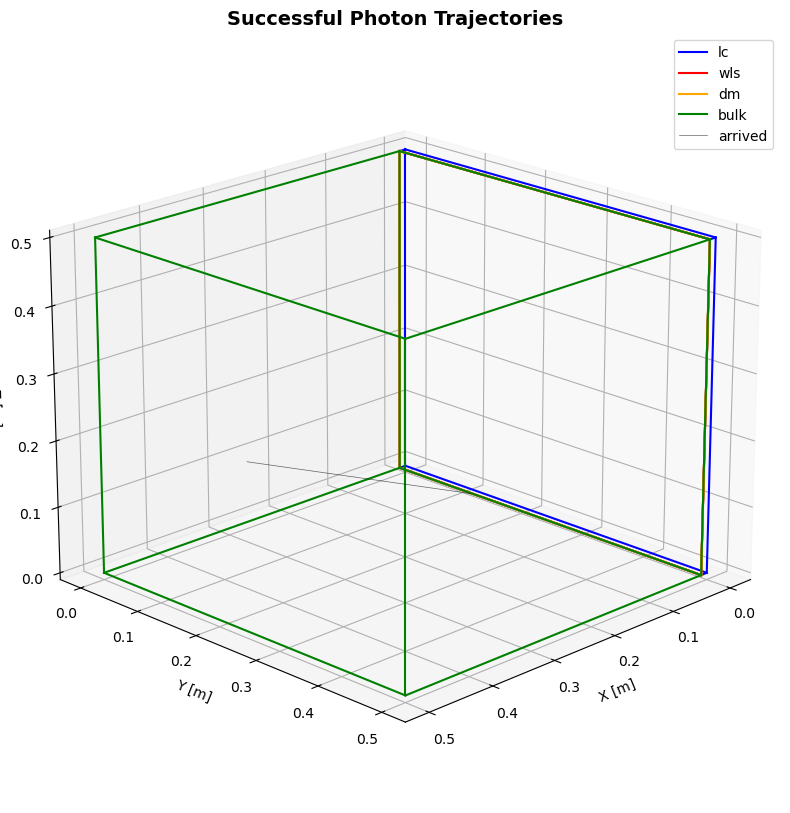

Plotted 1 of 1 arrived photons


In [15]:
# Photon trajectories (arrived photons only)
if n_arrived > 0:
    fig = plot_trajectories(
        df[df['event_type'] == 'arrived'],
        volumes,
        event_types=['arrived'],
        max_per_type=min(100, n_arrived),  # Plot up to 100
        alpha=0.6,
        figsize=(12, 10)
    )
    ax = fig.gca()
    ax.set_title("Successful Photon Trajectories", fontsize=14, fontweight='bold')
    ax.view_init(elev=20, azim=45)
    plt.show()
    print(f"Plotted {min(100, n_arrived)} of {n_arrived} arrived photons")
else:
    print("No arrived photons to plot. Try increasing max_thrown.")

## 9. Detailed Analysis

Let's look at the properties of photons that successfully reached the sensors.

In [16]:
# Statistics for arrived photons
if n_arrived > 0:
    arrived = df[df['event_type'] == 'arrived']

    print("Statistics for ARRIVED photons:")
    print("=" * 60)
    print(f"Number of reflections:")
    print(f"  Mean: {arrived['n_reflections'].mean():.2f}")
    print(f"  Min:  {arrived['n_reflections'].min():.0f}")
    print(f"  Max:  {arrived['n_reflections'].max():.0f}")
    print()
    print(f"Total internal reflections:")
    print(f"  Mean: {arrived['n_tir'].mean():.2f}")
    print()
    print(f"Refractions:")
    print(f"  Mean: {arrived['n_refractions'].mean():.2f}")
    print()
    print(f"Path length:")
    print(f"  Mean: {arrived['path_length'].mean():.3f} m")
    print(f"  Min:  {arrived['path_length'].min():.3f} m")
    print(f"  Max:  {arrived['path_length'].max():.3f} m")
    print("=" * 60)
else:
    print("No arrived photons for detailed analysis.")

Statistics for ARRIVED photons:
Number of reflections:
  Mean: 0.00
  Min:  0
  Max:  0

Total internal reflections:
  Mean: 0.00

Refractions:
  Mean: 0.00

Path length:
  Mean: 0.563 m
  Min:  0.563 m
  Max:  0.563 m


In [17]:
# Wavelength evolution
if n_arrived > 0:
    print("\nWavelength evolution examples:")
    print("=" * 60)
    for i, wl_hist in enumerate(arrived['wavelength_history'].head(5)):
        wavelengths = [float(x) for x in wl_hist.split(';')]
        print(f"Photon {i+1}: {' → '.join(f'{w:.0f} nm' for w in wavelengths)}")
    print("=" * 60)
    print("\nTypical cascade: 128 nm (VUV) → 420 nm (blue) → 490 nm (green)")


Wavelength evolution examples:
Photon 1: 128 nm

Typical cascade: 128 nm (VUV) → 420 nm (blue) → 490 nm (green)


## 10. Save Results

In [18]:
# Save to CSV
output_file = "simulation_results.csv"
df.to_csv(output_file, index=False)
print(f"✓ Results saved to: {output_file}")
print(f"  Columns: {list(df.columns)}")
print(f"  Rows: {len(df):,}")

✓ Results saved to: simulation_results.csv
  Columns: ['trajectory', 'event_type', 'arrived', 'lost', 'n_reflections', 'n_tir', 'n_refractions', 'path_length', 'wavelength_history']
  Rows: 10,000


## Summary

This notebook demonstrated:

1. ✅ **Geometry definition** - Creating multi-layer optical volumes
2. ✅ **Material properties** - Wavelength-dependent n, absorption, emission
3. ✅ **Simulation setup** - Configuring and running Monte Carlo simulation
4. ✅ **Analysis tools** - Built-in plotting and efficiency calculations
5. ✅ **Results interpretation** - Understanding photon behavior

### Key Findings:

- **Low efficiency** (~0.025%) is dominated by **geometric acceptance** (~6.4% solid angle)
- Photons undergo complex wavelength conversion: VUV → blue → green
- Multiple reflections and refractions before detection
- Most photons are lost in bulk before reaching detector region

### Next Steps:

- Increase detector area to improve geometric acceptance
- Add reflective enclosure to recover bulk losses
- Optimize wavelength shifter properties
- Study different source positions

### Further Reading:

- **Detailed validation**: See [`PHYSICS_VALIDATION.md`](PHYSICS_VALIDATION.md)
- **Model limitations**: See [`README.md`](README.md#physics-validation)
- **Example scripts**: `examples/example_with_gap.py`, `examples/physics_validation.py`